In [214]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Logistic Regression on Iris Dataset

Goal: Build a clean, reusable Logistic Regression / classification pipeline.
Focus: clarity, consistency, and end-to-end ML workflow.

In [215]:
from sklearn.datasets import load_iris

In [216]:
data = load_iris()

In [217]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [218]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [219]:
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

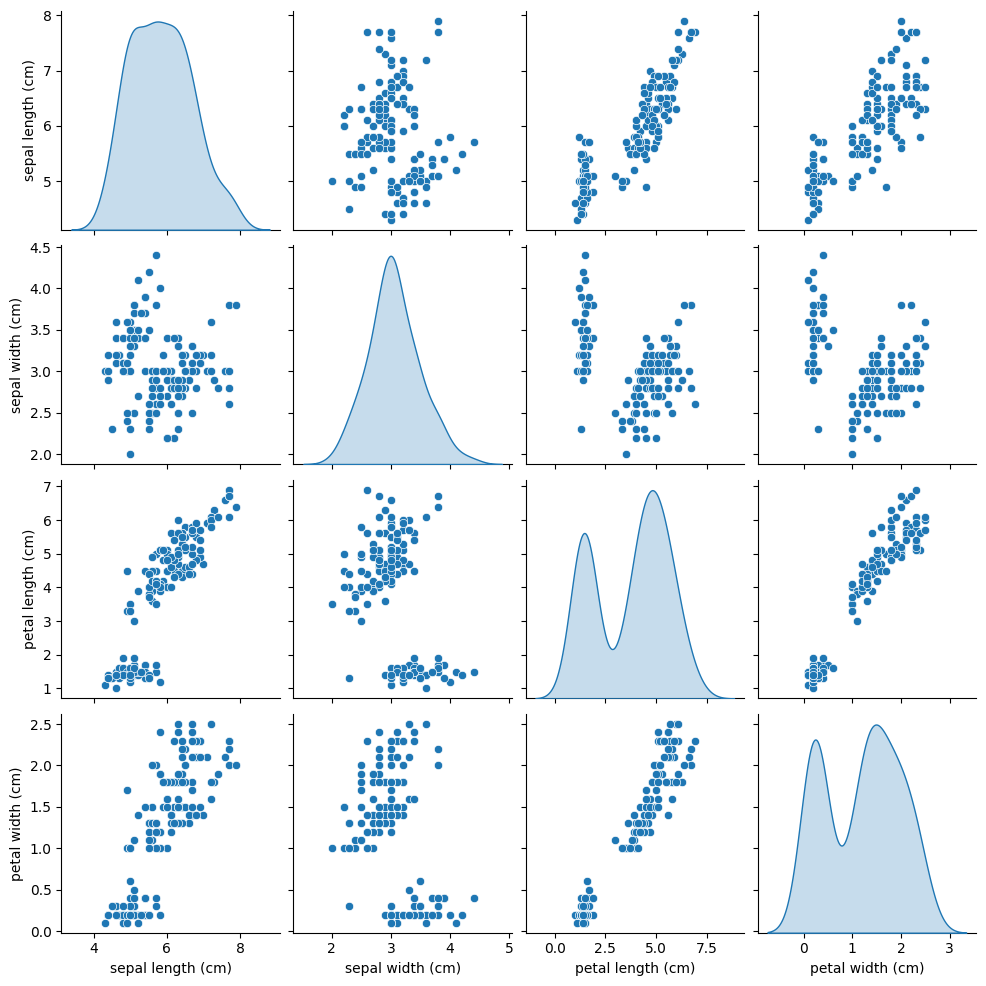

In [220]:
sns.pairplot(pd.DataFrame(data.data, columns=data.feature_names), diag_kind='kde')

In [221]:
X = data.data   #independent variables
y = data.target  #dependent varaible

# Feature–Target Separation
X contains the input features, y contains the class labels

In [222]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [241]:
X = pd.DataFrame(data.data , columns=data.feature_names)
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [242]:
y = pd.Series(data.target, name='target')
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [225]:
df = X.copy()
df["species"] = data.target_names[y]


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

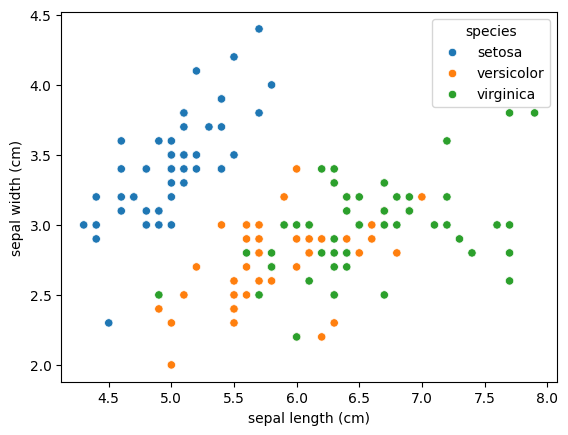

In [226]:
sns.scatterplot(data=df, x= 'sepal length (cm)', y='sepal width (cm)', hue='species')

<Axes: >

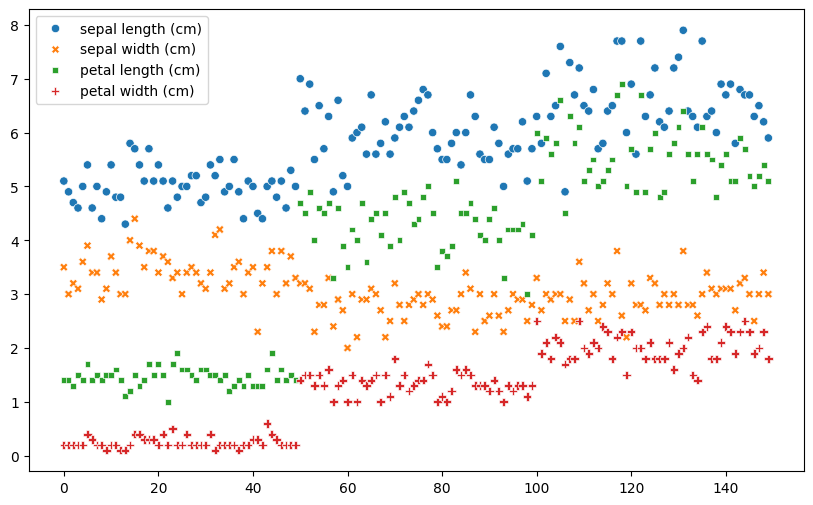

In [227]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=X)

<Axes: >

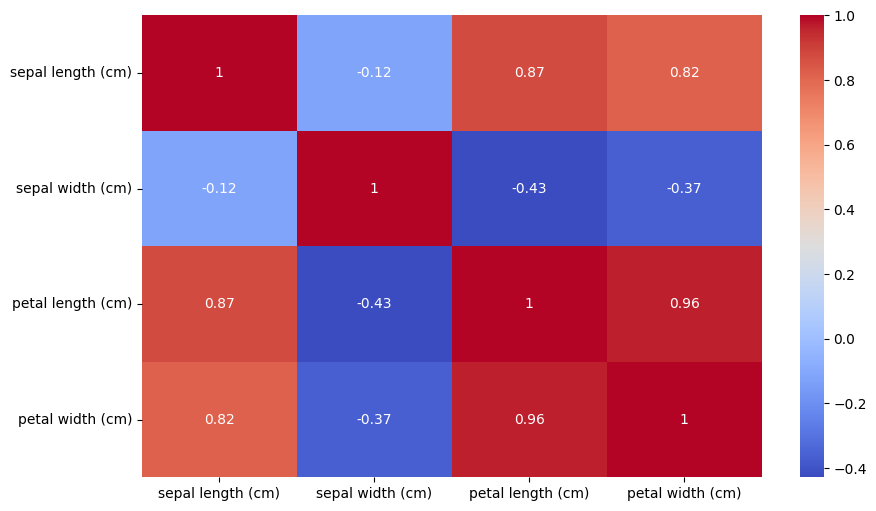

In [228]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

In [229]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [230]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [231]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
scaler.fit(X_train) 

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [232]:
X_test_scaled = pd.DataFrame( X_test_scaled, columns=X.columns, index=X_test.index )
X_test_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,0.354517,-0.585060,0.557775,0.022248
18,-0.133071,1.650837,-1.161395,-1.179118
118,2.304867,-1.032239,1.818500,1.490583
78,0.232620,-0.361470,0.443164,0.422703
76,1.207795,-0.585060,0.615081,0.289218


In [233]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_train_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,-1.473937,1.203658,-1.562535,-1.312603
15,-0.133071,2.992376,-1.276006,-1.045633
65,1.085898,0.085709,0.385858,0.289218
11,-1.230143,0.756479,-1.218701,-1.312603
42,-1.717731,0.309299,-1.390618,-1.312603


In [234]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score,confusion_matrix,classification_report
lr = LogisticRegression(max_iter=200)

In [235]:
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)

In [236]:
score=accuracy_score(y_test,y_pred)
print("Accuracy Score:", score)

cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cm)
cr=classification_report(y_test,y_pred)
print("Classification Report:\n", cr)

Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [237]:
print("intercept:",lr.intercept_)
intercept_df= pd.DataFrame(lr.intercept_, columns=['intercept'], index=data.target_names)
intercept_df

intercept: [-0.13377225  1.98264649 -1.84887424]


,intercept
setosa,-0.133772
versicolor,1.982646
virginica,-1.848874


In [238]:
coef_df = pd.DataFrame( lr.coef_,
    columns=X.columns,
    index=data.target_names
)
coef_df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.003166,1.144873,-1.811348,-1.69251
versicolor,0.527990,-0.283200,-0.340607,-0.72014
virginica,0.475175,-0.861673,2.151955,2.41265


In [244]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

new_flower_scaled = scaler.transform(new_flower)
prediction = lr.predict(new_flower_scaled)

print(data.target_names[prediction])


['setosa']


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [243]:
new_flower = [[6.1, 2.8, 4.7, 1.2]]
new_flower_scaled = scaler.transform(new_flower)
prediction = lr.predict(new_flower_scaled)

data.target_names[prediction[0]]


C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\burha\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


np.str_('versicolor')

## Conclusion

Logistic Regression performs well on the Iris dataset due to its linear separability.
Feature scaling improves optimization stability.
Petal measurements contribute most strongly to class separation.